# Contrastive Learning con MNIST
Este notebook explica **qué se hizo, por qué y cómo presentarlo**. Reutiliza `src/` y los resultados reales de `outputs/quick/`; no duplica la implementación.

> **Importante:** `quick` es una prueba de funcionamiento con una semilla y muy pocas épocas. Sus números no son conclusiones generales.

## 1. La pregunta
Tenemos muchas imágenes, pero suponemos que **etiquetarlas cuesta dinero**. Preguntamos: ¿aprender primero de todas las imágenes sin etiquetas ayuda después a reconocer dígitos usando pocas etiquetas?

- **CNN supervisada:** un alumno estudia ejercicios que incluyen la solución.
- **SimCLR:** primero observa muchos dibujos sin soluciones y aprende qué transformaciones conservan su identidad; después recibe unas pocas soluciones.
- **Regresión logística:** una regla supervisada mucho más sencilla, usada como referencia.

No suponemos que SimCLR ganará: lo medimos.

## 2. El experimento en un dibujo
```text
                    12.000 imágenes de entrenamiento
                                  │
                 ┌────────────────┼────────────────┐
                 │                │                │
          CNN supervisada       SimCLR       Regresión logística
          usa etiquetas       preentrena         usa etiquetas
          desde el inicio     sin etiquetas       desde el inicio
                 │                │                │
                 │         encoder congelado      │
                 │         + capa lineal          │
                 └────────────────┼────────────────┘
                                  │
                    mismas etiquetas disponibles
                         1%, 10% o 100%
                                  │
                      examen final: test
```
Los tres métodos reciben exactamente los mismos IDs etiquetados en cada presupuesto.

## 3. Diccionario mínimo
| Palabra | Significado sencillo |
|---|---|
| **Etiqueta** | Respuesta correcta: 0, 1, ..., 9. |
| **Train** | Datos usados para ajustar el modelo. |
| **Validation** | Datos usados para decidir cuándo parar o qué opción elegir. |
| **Test** | Examen final; no se usa para tomar decisiones. |
| **CNN** | Red que detecta patrones locales de una imagen. |
| **Encoder** | Parte que convierte una imagen en características. |
| **Embedding** | Vector numérico que resume una imagen. |
| **Época** | Una pasada por todos los ejemplos de train. |
| **Batch** | Grupo de ejemplos procesado a la vez. |
| **Loss** | Número que cuantifica el error durante el entrenamiento. |
| **Linear probe** | Clasificador lineal sobre un encoder congelado. |
| **Semilla** | Número que permite repetir decisiones aleatorias. |

## 4. Preparación
Abre el notebook desde la raíz del repositorio. En Colab, clona o sube primero el proyecto y descomenta la instalación.

In [1]:
# Solo en un entorno nuevo o en Google Colab:
# !python3 -m pip install -r requirements.txt

In [ ]:
from pathlib import Path
import json
import sys
import numpy as np
import pandas as pd

ROOT = Path.cwd()
if not (ROOT / 'src').exists() and (ROOT.parent / 'src').exists():
    ROOT = ROOT.parent
assert (ROOT / 'src').exists(), 'Abre el notebook dentro del repositorio.'
sys.path.insert(0, str(ROOT))

from src import visualization as _matplotlib_macos_bootstrap
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display

# ===== CONTROLES DEL EXPERIMENTO =====
# Usa 'quick' para una demostración y 'full' para los resultados finales.
MODE = 'quick'
# Cambia a True cuando quieras entrenar desde este notebook.
RUN_EXPERIMENT = True
# Solo deben activarse si ya existen resultados compatibles del mismo modo.
REUSE_PRETRAINING = False
REUSE_LOGISTIC = False

OUT = ROOT / 'outputs' / MODE
FIG = OUT / 'figures'
print('Repositorio:', ROOT)
print('Modo seleccionado:', MODE)
print('Resultados disponibles:', (OUT / 'metrics.csv').exists())

Repositorio: /Users/nataliaburguillomartin/Documents/TELECO/MUIT/PDRL & MLLB/Contrastive learning
Modo seleccionado: quick
Resultados disponibles: True


## Ejecutar el experimento directamente desde el notebook

En la celda anterior elige `MODE = 'quick'` o `MODE = 'full'` y cambia `RUN_EXPERIMENT = True`. La celda siguiente llama al pipeline completo: descarga MNIST si es necesario, crea las particiones, preentrena SimCLR, entrena los clasificadores, evalúa y genera todas las tablas y figuras.

- Empieza siempre por `quick`.
- Usa `full` solamente para el experimento final; con CPU puede tardar horas.
- Al terminar, vuelve a poner `RUN_EXPERIMENT = False` para poder ejecutar las celdas explicativas sin repetir el entrenamiento.
- `REUSE_PRETRAINING` y `REUSE_LOGISTIC` permiten reutilizar esos resultados, pero solo cuando proceden exactamente del mismo modo y configuración.

In [3]:
import subprocess

if MODE not in {'quick', 'full'}:
    raise ValueError("MODE debe ser 'quick' o 'full'.")

if RUN_EXPERIMENT:
    command = [sys.executable, '-m', 'src.run_experiment', '--mode', MODE]
    if REUSE_PRETRAINING:
        command.append('--reuse-pretraining')
    if REUSE_LOGISTIC:
        command.append('--reuse-logistic')
    print('Ejecutando:', ' '.join(command))
    subprocess.run(command, cwd=ROOT, check=True)

metrics_path = OUT / 'metrics.csv'
if not metrics_path.exists():
    raise FileNotFoundError(
        f'No hay resultados para {MODE}. Pon RUN_EXPERIMENT = True y ejecuta esta celda.'
    )
print('Resultados listos en:', OUT)

Ejecutando: /Users/nataliaburguillomartin/Documents/TELECO/MUIT/PDRL & MLLB/Contrastive learning/.venv/bin/python -m src.run_experiment --mode quick
Mode=quick; device=cpu; output=outputs/quick

Seed 42 (1/1)


/Users/nataliaburguillomartin/Documents/TELECO/MUIT/PDRL & MLLB/Contrastive learning/src/visualization.py:27: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


  Labels 1%: n=120, batch=16, max epochs supervised/probe=8/8
  Labels 10%: n=1200, batch=60, max epochs supervised/probe=3/5
  Labels 100%: n=12000, batch=128, max epochs supervised/probe=3/5

Complete. Metrics: outputs/quick/metrics.csv
Resultados listos en: /Users/nataliaburguillomartin/Documents/TELECO/MUIT/PDRL & MLLB/Contrastive learning/outputs/quick


## 5. Datos y particiones
MNIST contiene imágenes grises de 28×28 y diez clases. En `quick` usamos 12.000 imágenes para entrenar, 2.000 para validar y 2.000 del test oficial. En `full` usamos 48.000/12.000/10.000. La variable `MODE` decide qué resultados carga el resto del notebook.

Las particiones son **estratificadas**, por lo que conservan aproximadamente la proporción de cada dígito. Train y validation no se solapan. Los índices de test pertenecen a otro conjunto oficial.

In [4]:
config = json.loads((OUT / 'config.json').read_text())
splits = json.loads((OUT / 'split_indices_seed_42.json').read_text())
sizes = pd.DataFrame({
    'partición': ['train', 'validation', 'test'],
    'imágenes': [len(splits['train']), len(splits['val']), len(splits['test'])],
    'uso': ['ajustar modelos', 'seleccionar/parar', 'evaluación final'],
})
display(sizes)
print('Solapamiento train-validation:', len(set(splits['train']) & set(splits['val'])))

,partición,imágenes,uso
0,train,12000,ajustar modelos
1,validation,2000,seleccionar/parar
2,test,2000,evaluación final


Solapamiento train-validation: 0


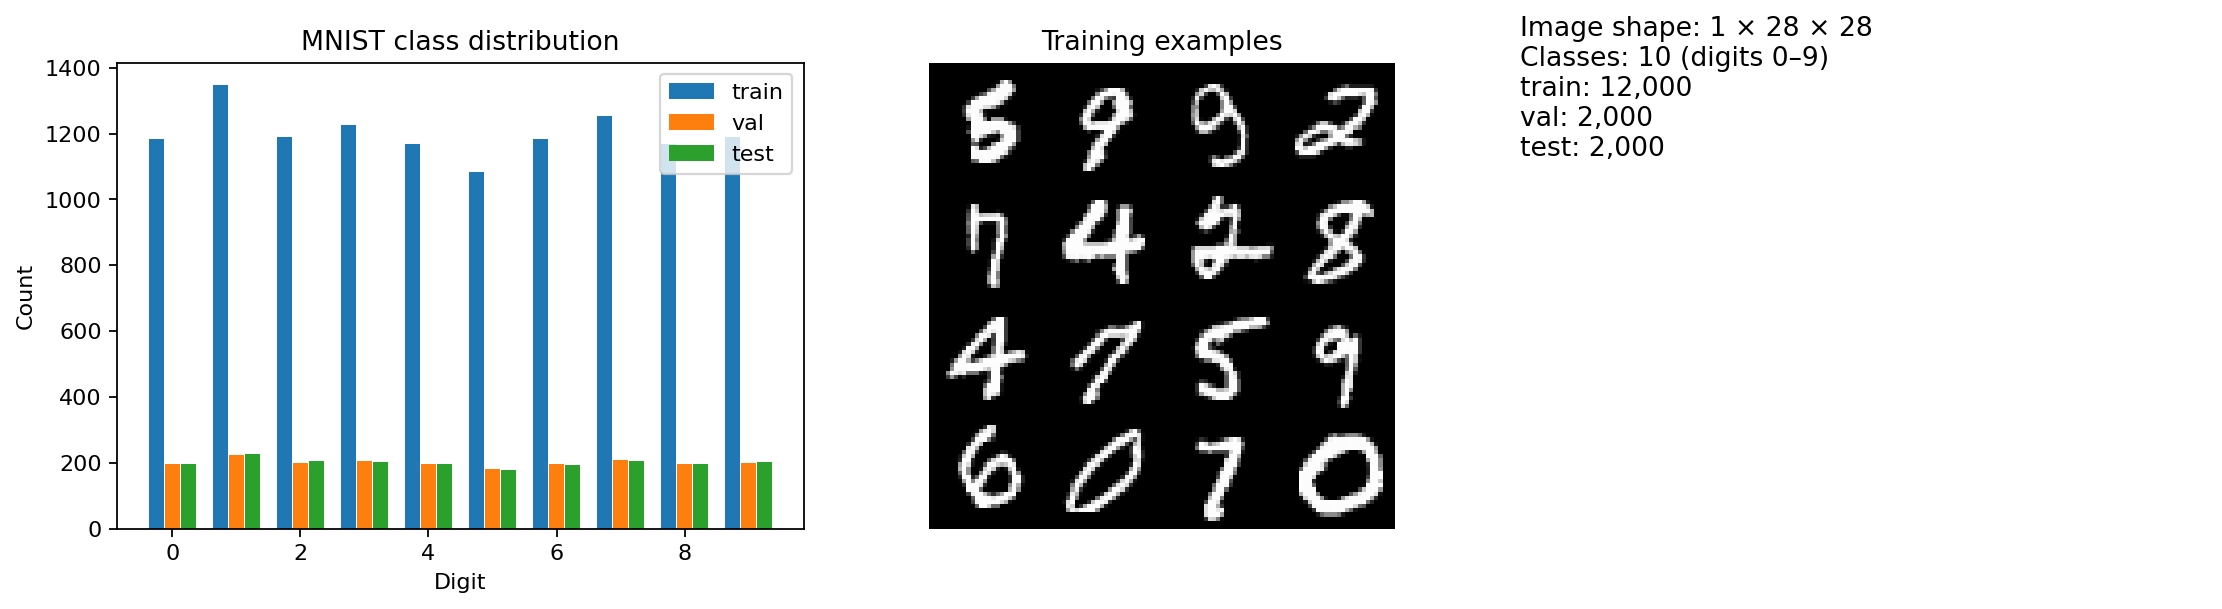

In [5]:
display(Image.open(FIG / 'eda_mnist.png'))

## 6. ¿Qué significa 1%, 10% y 100%?
Las 12.000 imágenes existen siempre. Cambia cuántas respuestas correctas permitimos utilizar en las fases supervisadas:

- 1% = 120 etiquetas.
- 10% = 1.200 etiquetas.
- 100% = 12.000 etiquetas.

SimCLR observa las 12.000 imágenes durante el preentrenamiento, pero no recibe sus etiquetas.

In [6]:
rows = []
for fraction, name in [(0.01, '001pct'), (0.10, '010pct'), (1.0, '100pct')]:
    ids = json.loads((OUT / f'labelled_ids_seed_42_{name}.json').read_text())
    rows.append({'porcentaje': f'{fraction:.0%}', 'etiquetas disponibles': len(ids)})
display(pd.DataFrame(rows))

,porcentaje,etiquetas disponibles
0,1%,120
1,10%,1200
2,100%,12000


## 7. Métodos y control experimental
### A. CNN supervisada
Recibe una imagen y su respuesta correcta. Cross-entropy penaliza que dé poca probabilidad al dígito correcto. Toda la CNN cambia durante el entrenamiento.
```text
imagen + etiqueta → encoder CNN → clasificador → probabilidades 0…9
```
### B. SimCLR + linear probe
Primero aprende sin etiquetas comparando dos transformaciones de una imagen. Después congelamos el encoder y entrenamos solo una capa lineal.
```text
pretrain: imagen → dos vistas → encoder → projection head → NT-Xent
probe:    imagen → encoder congelado → capa lineal → dígito
```
### C. Encoder aleatorio + el mismo linear probe
Es el control clave: congelamos la misma CNN sin preentrenarla. La diferencia `SimCLR probe − random probe` mide directamente qué aportó el preentrenamiento contrastivo.

### D. Regresión logística
Convierte los 28×28 píxeles en 784 números y aprende fronteras lineales. Es una referencia sencilla y supervisada.

In [7]:
import torch
from src.models import CompactEncoder, Classifier, SimCLR
example = torch.zeros(4, 1, 28, 28)
encoder = CompactEncoder(128)
classifier = Classifier(encoder, 128)
simclr = SimCLR(CompactEncoder(128), 128, 64)
print('Entrada:', tuple(example.shape), '= 4 imágenes, 1 canal, 28×28')
print('Embedding:', tuple(encoder(example).shape), '= 128 características por imagen')
print('Clasificador:', tuple(classifier(example).shape), '= 10 puntuaciones por imagen')
print('Proyección SimCLR:', tuple(simclr(example).shape))
print('Parámetros de la CNN:', f'{sum(p.numel() for p in classifier.parameters()):,}')

Entrada: (4, 1, 28, 28) = 4 imágenes, 1 canal, 28×28
Embedding: (4, 128) = 128 características por imagen
Clasificador: (4, 10) = 10 puntuaciones por imagen
Proyección SimCLR: (4, 64)
Parámetros de la CNN: 110,922


## 8. Cross-entropy, explicado fácil
Si la imagen es un 7 y el modelo solo asigna 20% de probabilidad al 7, recibe una penalización alta. El optimizador modifica la red para aumentar esa probabilidad. Para calcular esta pérdida necesitamos conocer la etiqueta correcta.

## 9. Cómo aprende SimCLR sin etiquetas
De cada imagen crea dos vistas independientes con rotación pequeña, traslación, escala y ruido. No usamos flips porque podrían modificar la identidad de un dígito. Ejecuta esta celda varias veces para ver que las vistas cambian.

In [8]:
from torchvision.datasets import MNIST
from src.data import contrastive_transform
mnist = MNIST(ROOT / 'data', train=True, download=True)
original, label = mnist[0]
augment = contrastive_transform()
view_1, view_2 = augment(original), augment(original)
fig, axes = plt.subplots(1, 3, figsize=(9, 3))
axes[0].imshow(original, cmap='gray'); axes[0].set_title(f'Original (etiqueta {label})')
axes[1].imshow(view_1.squeeze(), cmap='gray'); axes[1].set_title('Vista 1')
axes[2].imshow(view_2.squeeze(), cmap='gray'); axes[2].set_title('Vista 2')
for ax in axes: ax.axis('off')
plt.tight_layout()
print('La etiqueta se muestra solo para entender la figura; no entra en NT-Xent.')

La etiqueta se muestra solo para entender la figura; no entra en NT-Xent.


### Positivos, negativos y NT-Xent
Las dos vistas de la misma imagen son un **positivo** y deben aproximarse. Las vistas de otras imágenes del batch son **negativos** y deben distinguirse.
```text
misma imagen: vista 1 ← acercar → vista 2
otra imagen:  vista 1 ← separar → otras vistas
```
NT-Xent calcula estas relaciones con vectores normalizados. La temperatura es 0.5 y la diagonal se enmascara para que una vista no se compare consigo misma.

Limitación: dos imágenes diferentes pueden contener el mismo dígito, pero SimCLR las trata como negativas porque no mira etiquetas.

### Projection head y linear probe
La projection head solo ayuda a optimizar NT-Xent y se elimina después. Conservamos el embedding del encoder.

Para el **linear probe**, congelamos el encoder y entrenamos una capa lineal. Si funciona, la información sobre el dígito ya estaba accesible en los embeddings. Esto distingue una buena representación de un buen clasificador final.

## 10. Qué está igualado
| Aspecto | Situación |
|---|---|
| Arquitectura CNN/SimCLR | Exactamente el mismo encoder. |
| IDs etiquetados | Los mismos para los tres métodos. |
| Train, validation y test | Los mismos. |
| Número de etiquetas | El mismo. |
| Imágenes observadas | SimCLR ve todas sin etiqueta antes del probe. |
| Cómputo | SimCLR añade preentrenamiento. |

Estudiamos **eficiencia de etiquetas**, no igualdad de tiempo de cómputo.

## 11. Curvas de entrenamiento
Una loss descendente indica que se resuelve mejor el objetivo de entrenamiento, pero no garantiza mejor accuracy de test.

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].imshow(Image.open(FIG / 'contrastive_loss.png')); axes[0].axis('off'); axes[0].set_title('Preentrenamiento SimCLR')
axes[1].imshow(Image.open(FIG / 'supervised_curves.png')); axes[1].axis('off'); axes[1].set_title('CNN supervisada, 100%')
plt.tight_layout()

## 12. Métricas
- **Accuracy:** porcentaje total de aciertos.
- **Precision macro:** fiabilidad de las predicciones, calculada por dígito y promediada.
- **Recall macro:** proporción encontrada de cada dígito, promediada.
- **F1 macro:** equilibrio entre precision y recall.
- **Matriz de confusión:** enseña qué dígitos se confunden.

`macro` da el mismo peso a cada clase.

In [10]:
metrics = pd.read_csv(OUT / 'metrics.csv')
shown = metrics[['method','label_fraction','labelled_samples','accuracy','precision_macro','recall_macro','f1_macro','runtime_seconds']].copy()
shown['label_fraction'] = (shown['label_fraction'] * 100).astype(int).astype(str) + '%'
display(shown.round(4))

,method,label_fraction,labelled_samples,accuracy,precision_macro,recall_macro,f1_macro,runtime_seconds
0,Supervised CNN,1%,120,0.4120,0.5081,0.4038,0.3602,51.6150
1,SimCLR linear probe,1%,120,0.3820,0.3896,0.3744,0.3482,5.7534
2,Random encoder probe,1%,120,0.0990,0.0264,0.1031,0.0230,8.7340
3,Logistic regression,1%,120,0.7840,0.7859,0.7790,0.7786,5.8883
4,Supervised CNN,10%,1200,0.5740,0.6793,0.5636,0.5494,50.2899
5,SimCLR linear probe,10%,1200,0.4850,0.5144,0.4761,0.4323,10.4404
6,Random encoder probe,10%,1200,0.2040,0.0595,0.1904,0.0849,13.9405
7,Logistic regression,10%,1200,0.8735,0.8735,0.8715,0.8717,23.2863
8,Supervised CNN,100%,12000,0.9420,0.9473,0.9412,0.9416,148.4014
9,SimCLR linear probe,100%,12000,0.6945,0.6950,0.6872,0.6792,11.9725


In [11]:
table = metrics.pivot(index='method', columns='label_fraction', values='accuracy')
table.columns = ['1% etiquetas', '10% etiquetas', '100% etiquetas']
display(table.style.format('{:.2%}').highlight_max(axis=0, color='#b7e4c7'))
print('El verde marca el máximo observado en ESTE smoke test; no prueba superioridad general.')

,1% etiquetas,10% etiquetas,100% etiquetas
method,,,
Logistic regression,78.40%,87.35%,90.80%
Random encoder probe,9.90%,20.40%,24.25%
SimCLR linear probe,38.20%,48.50%,69.45%
Supervised CNN,41.20%,57.40%,94.20%


El verde marca el máximo observado en ESTE smoke test; no prueba superioridad general.


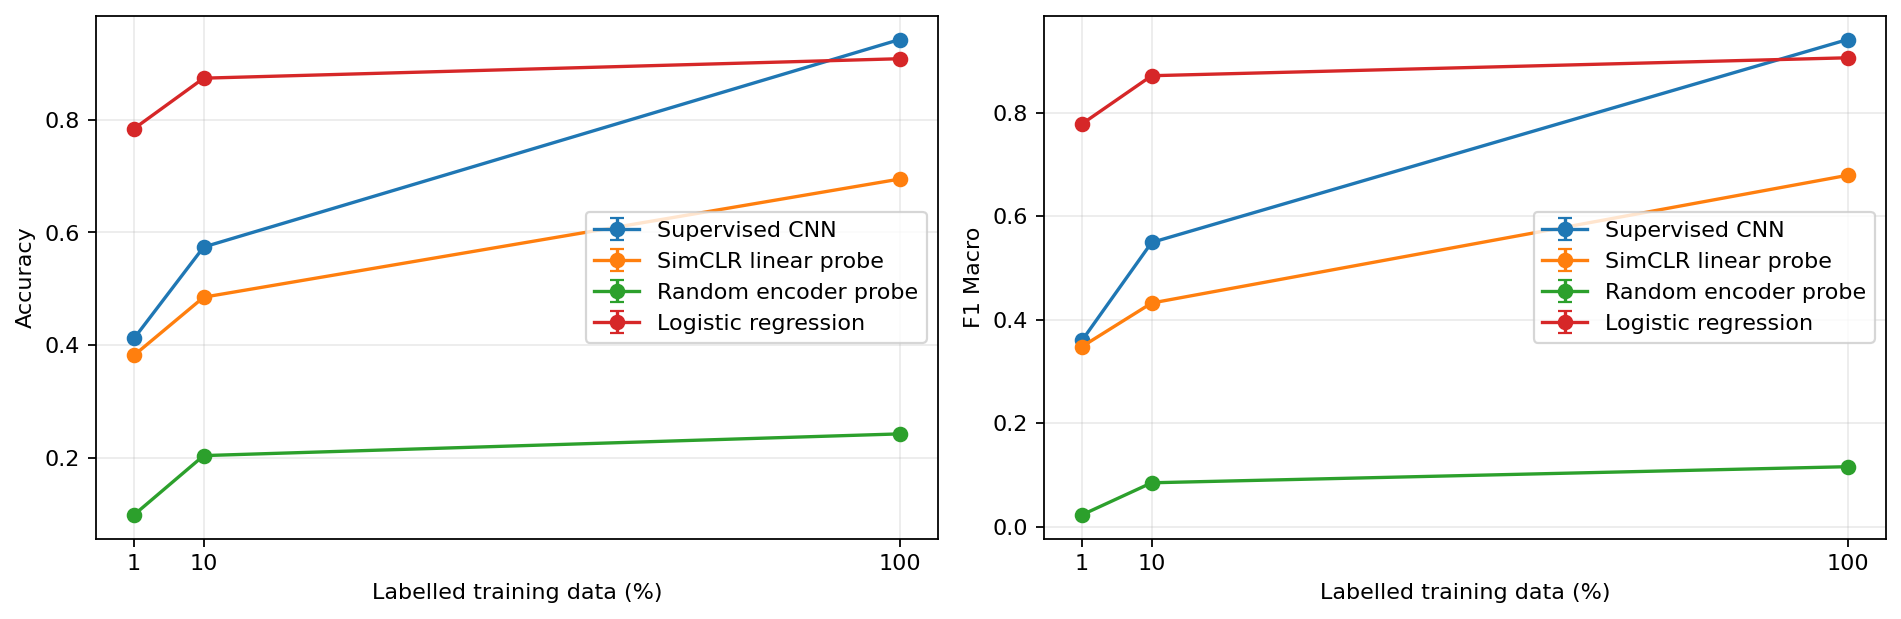

In [12]:
display(Image.open(FIG / 'method_comparison.png'))

### Interpretación correcta
Lee primero los resultados realmente cargados. Si aparece `Random encoder probe`, compáralo con `SimCLR linear probe`: esa diferencia es la evidencia directa de si el preentrenamiento añadió información linealmente útil.

La versión mejorada usa batch adaptativo y un mínimo de actualizaciones para evitar que el 1% reciba solo tres pasos. `quick` sigue siendo un smoke test: una semilla y dos épocas contrastivas. No permite afirmar que Contrastive Learning funcione o falle en general.

## 13. Matrices de confusión al 10%
Las filas son dígitos reales y las columnas las predicciones. Una buena matriz concentra valores en la diagonal.

In [13]:
names = [('CNN supervisada','confusion_supervised_010pct_seed_42.png'), ('SimCLR + probe','confusion_probe_010pct_seed_42.png'), ('Regresión logística','confusion_logistic_010pct_seed_42.png')]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (title, filename) in zip(axes, names):
    ax.imshow(Image.open(FIG / filename)); ax.axis('off'); ax.set_title(title)
plt.tight_layout()

## 14. PCA de embeddings
Cada embedding tiene 128 dimensiones. PCA lo reduce a dos ejes para dibujarlo. Cada punto es una imagen y el color su dígito real. Las etiquetas se usan **después de entrenar y solo para colorear**. Una separación bonita es sugerente, pero no sustituye las métricas.

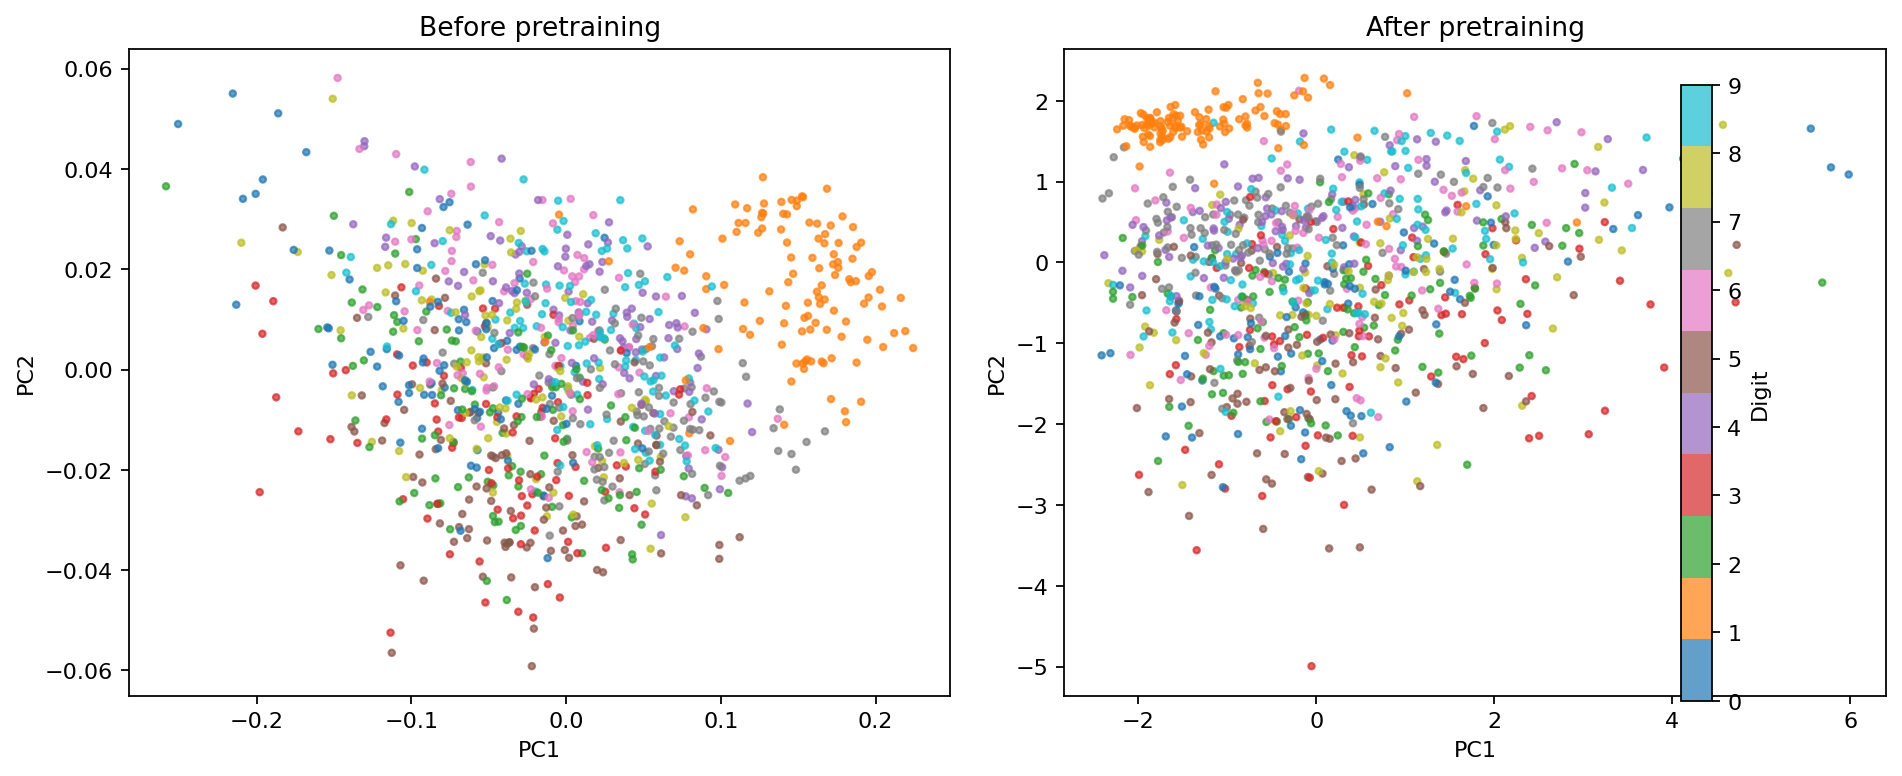

In [14]:
display(Image.open(FIG / 'embedding_pca.png'))

## 15. Diagnósticos centrados en Contrastive Learning
Después de repetir el modo `quick` o `full` con el pipeline mejorado aparecerán tres figuras nuevas:

- `positive_negative_similarity.png`: comprueba si las dos vistas positivas son más similares que vistas no emparejadas.
- `embedding_nearest_neighbors.png`: enseña qué imágenes recupera el embedding aleatorio y cuáles recupera SimCLR.
- `simclr_pretraining_gain.png`: resta la accuracy del probe aleatorio a la del probe SimCLR.

Estas pruebas estudian directamente la representación. Si todavía no has repetido el pipeline mejorado, la celda simplemente avisará de que faltan los archivos.

positive_negative_similarity.png


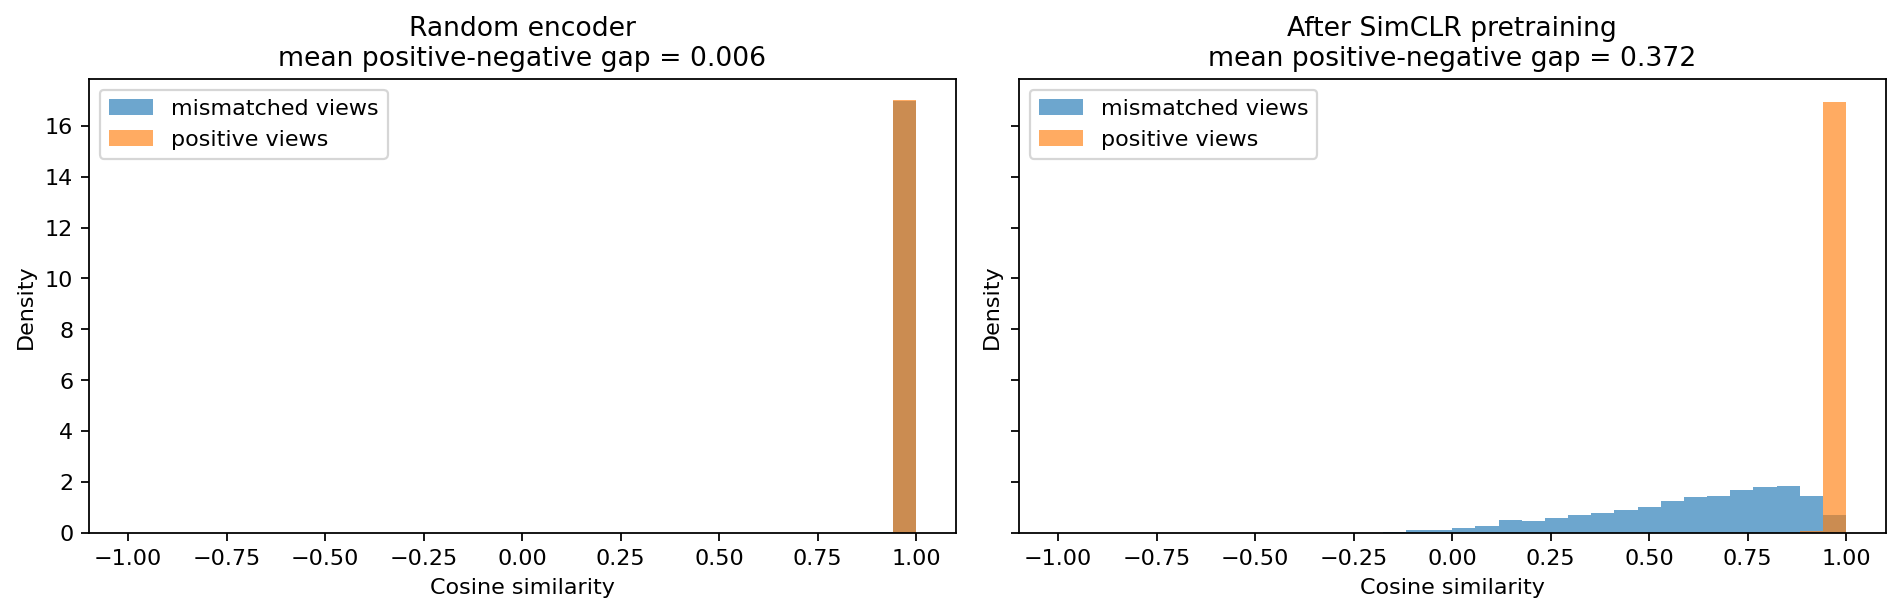

embedding_nearest_neighbors.png


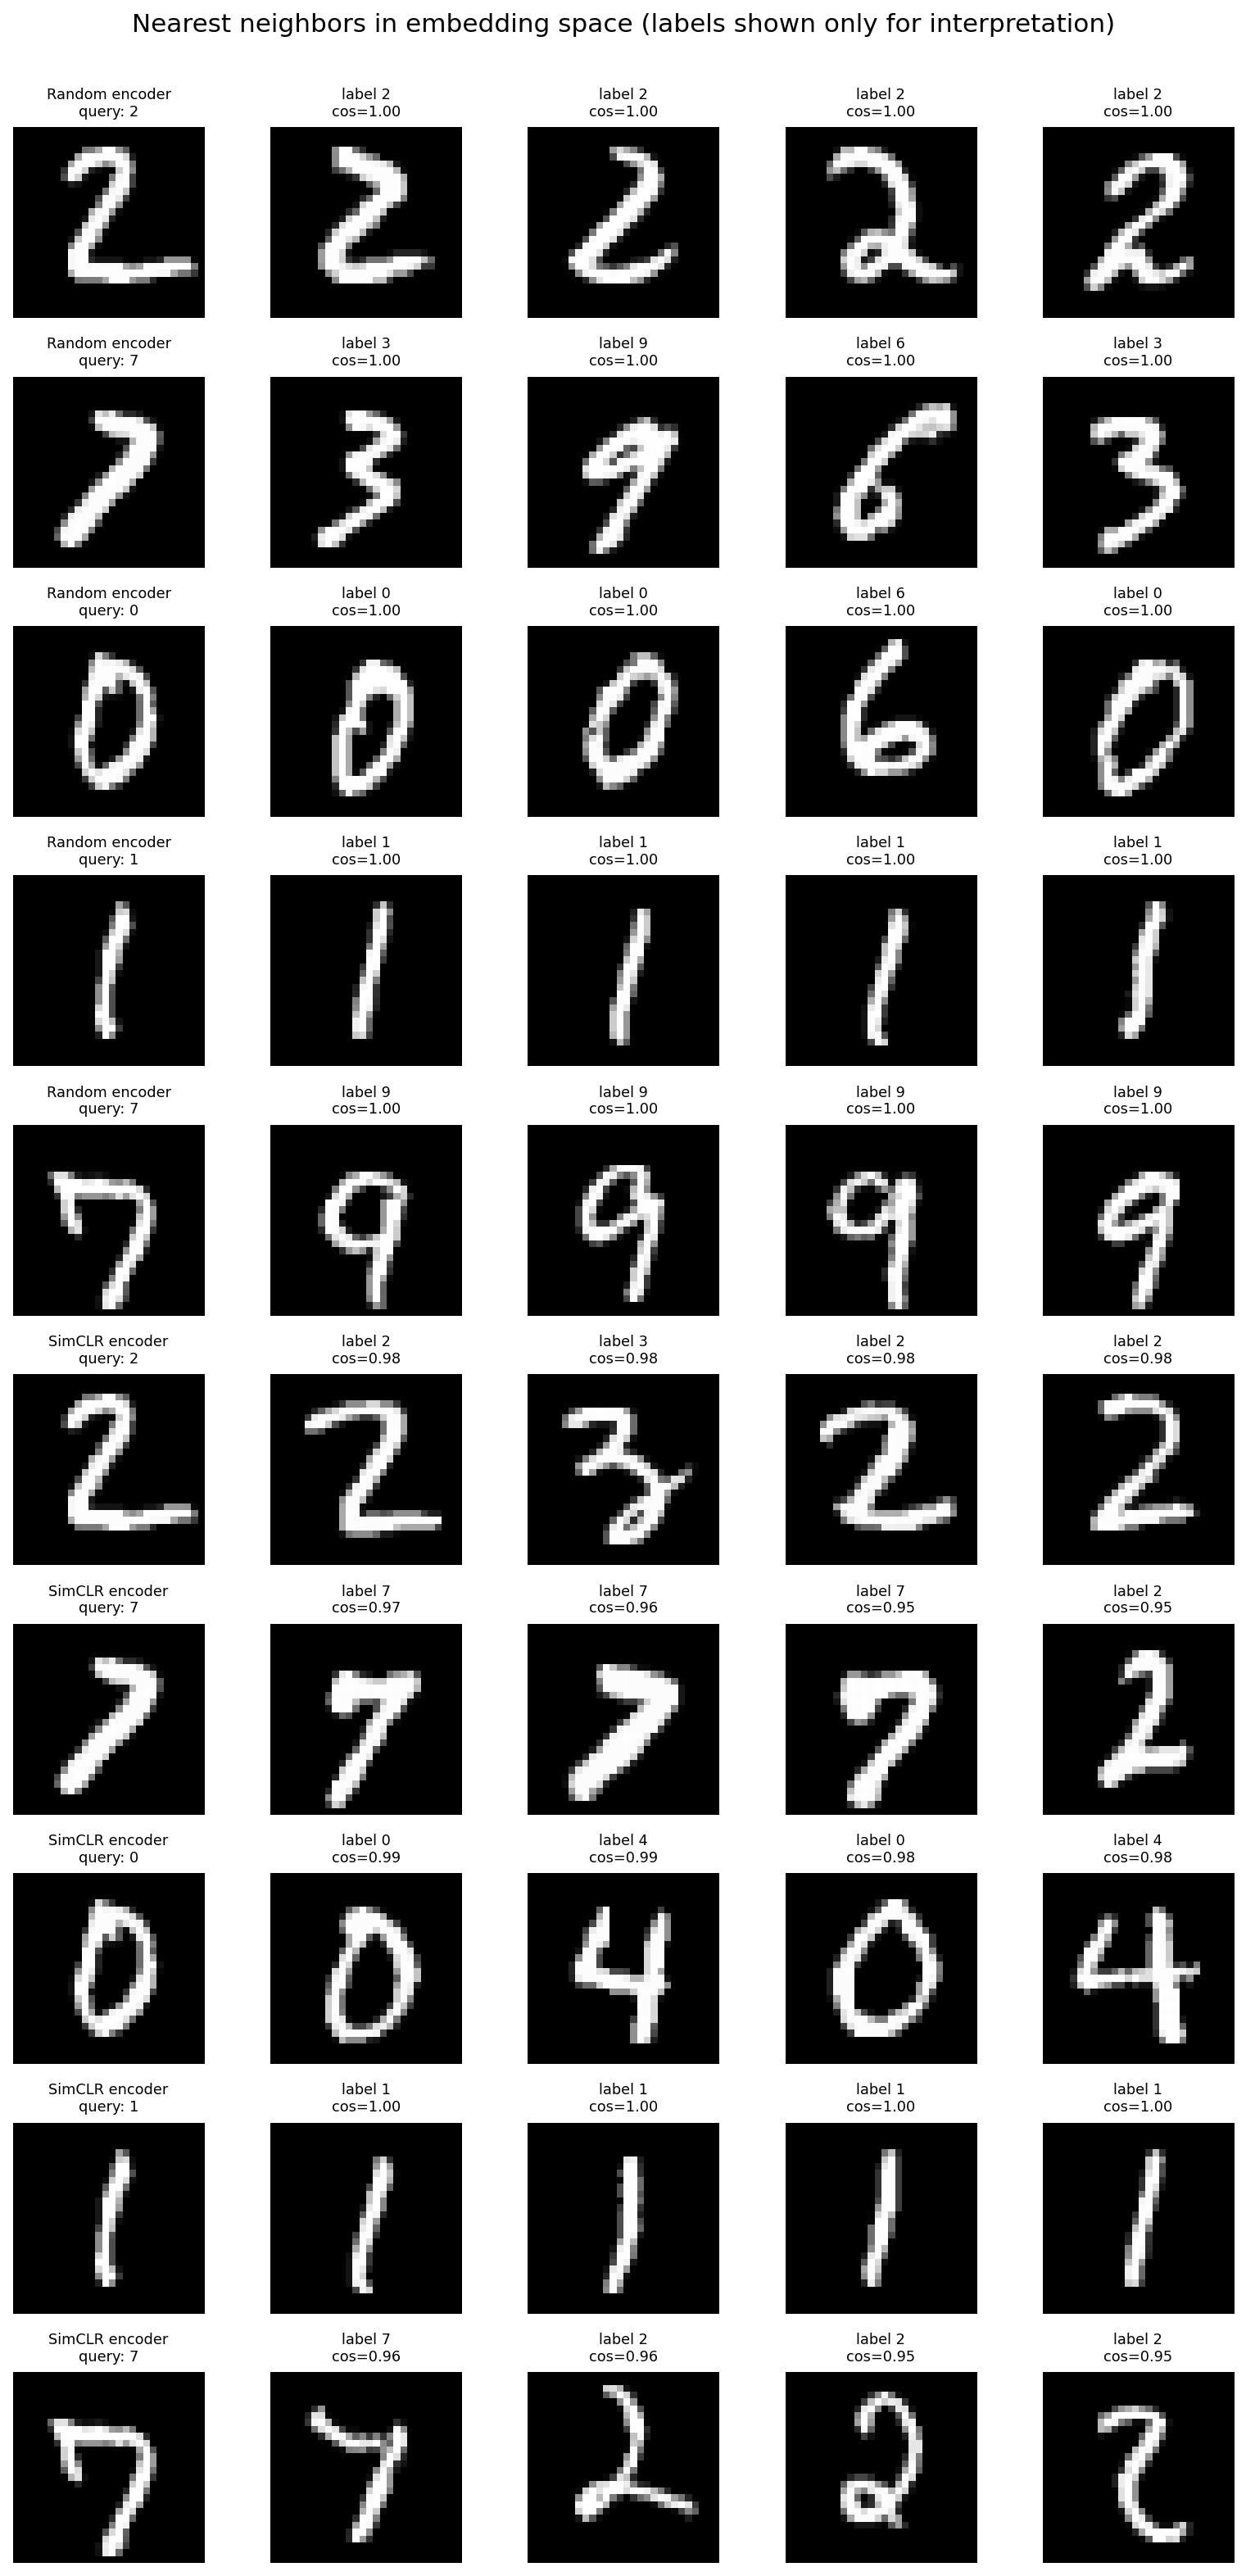

simclr_pretraining_gain.png


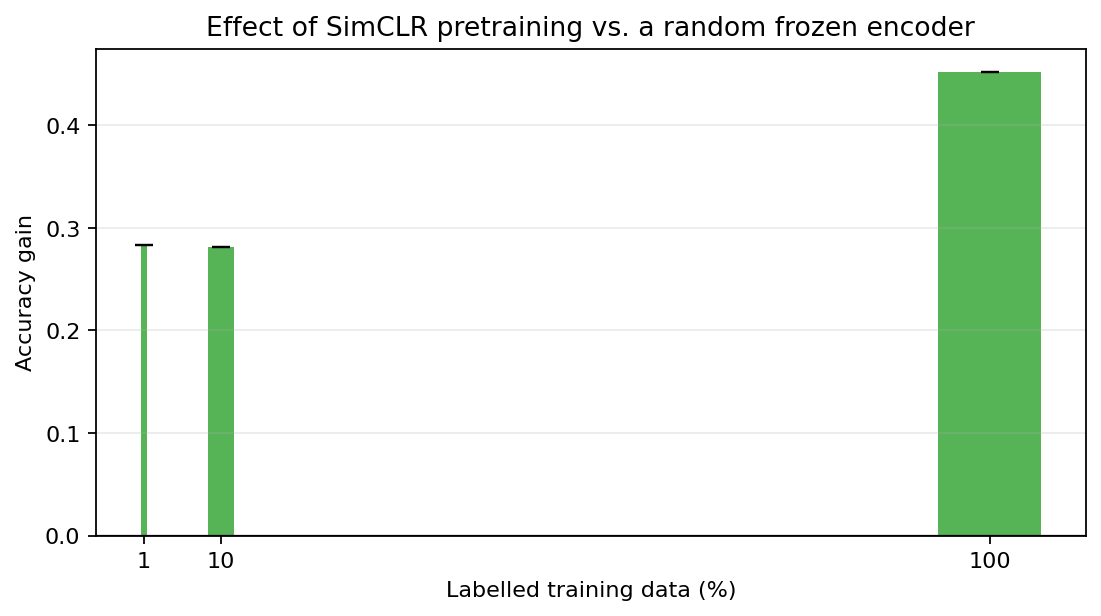

In [15]:
for filename in ['positive_negative_similarity.png', 'embedding_nearest_neighbors.png', 'simclr_pretraining_gain.png']:
    path = FIG / filename
    if path.exists():
        print(filename)
        display(Image.open(path))
    else:
        print(f'{filename}: pendiente de regenerar con el pipeline mejorado')

## 16. Conclusión normal
Construimos varios controles para reconocer dígitos y restringimos las etiquetas. SimCLR intentó aprender una representación sin conocer los dígitos y después comprobamos si una capa lineal podía leerla mejor que el mismo encoder aleatorio.

El pipeline funciona, respeta las particiones y genera métricas reales. Pero `quick` entrena demasiado poco para responder definitivamente si Contrastive Learning reduce la necesidad de etiquetas. Eso requiere `full`, varias semillas y más preentrenamiento.

## 17. Qué enseñar y qué decir en 5–10 minutos
### 1 — Problema (40 s)
**Enseña:** MNIST y 1%, 10%, 100%. **Di:** «Etiquetar cuesta; estudiamos si las imágenes sin etiqueta pueden enseñar primero una representación útil».

### 2 — Métodos (60 s)
**Enseña:** el diagrama. **Di:** «Comparamos CNN supervisada, SimCLR, un encoder aleatorio de control y regresión logística, con los mismos IDs etiquetados».

### 3 — SimCLR (60–90 s)
**Enseña:** original y dos vistas. **Di:** «Dos vistas de la misma imagen son positivas; las demás son negativas. NT-Xent aprende sin mirar la clase».

### 4 — Protocolo (45 s)
**Enseña:** 12.000/2.000/2.000. **Di:** «Validation decide; test es el examen final. Igualamos etiquetas, no cómputo».

### 5 — Resultados (90 s)
**Enseña:** `method_comparison.png` y `simclr_pretraining_gain.png`. **Di:** «La diferencia entre SimCLR y el encoder aleatorio aísla el efecto del preentrenamiento. Informamos lo observado sin asumir que deba ser positivo».

### 6 — Confusión y PCA (60 s)
**Enseña:** similitudes positivo/negativo y vecinos de embeddings; usa PCA como apoyo. **Di:** «Estos gráficos muestran directamente qué estructura aprendió el encoder».

### 7 — Cierre (45 s)
**Di:** «El pipeline demuestra la combinación autosupervisada-supervisada. Para evaluar la hipótesis seriamente faltan el modo completo y tres semillas».

## 18. Preguntas que pueden hacerte
**¿SimCLR es supervisado?** Es autosupervisado: no usa etiquetas humanas, pero crea su tarea con dos vistas.

**¿Por qué congelar el encoder?** Para medir lo que ya aprendió sin dejarlo adaptarse con etiquetas.

**¿Por qué no hay flips?** Podrían alterar la identidad de un dígito.

**¿Por qué logística funciona tan bien?** MNIST es sencillo, centrado y bastante separable con píxeles.

**¿Por qué SimCLR no ganó?** Puede depender de pocas épocas, batch, aumentos, arquitectura y simplicidad de MNIST.

**¿Es totalmente justa la comparación?** Iguala arquitectura y etiquetas, pero SimCLR usa más imágenes sin etiqueta y más cómputo.

## 19. Verificación
Las pruebas comprueban dimensiones, aumentos, NT-Xent, particiones, encoder congelado, ausencia de etiquetas en SimCLR y métricas.

In [16]:
import subprocess
result = subprocess.run([sys.executable, '-m', 'unittest', 'discover', '-s', 'tests', '-v'], cwd=ROOT)
assert result.returncode == 0, 'Alguna prueba ha fallado.'

test_linear_probe_freezes_encoder (test_pipeline.PipelineTests.test_linear_probe_freezes_encoder) ... ok
test_model_dimensions_and_shared_encoder_architecture (test_pipeline.PipelineTests.test_model_dimensions_and_shared_encoder_architecture) ... ok
test_multiclass_macro_metrics (test_pipeline.PipelineTests.test_multiclass_macro_metrics) ... ok
test_nt_xent_is_finite_and_backpropagates (test_pipeline.PipelineTests.test_nt_xent_is_finite_and_backpropagates) ... ok
test_similarity_diagnostic_matches_identical_views (test_pipeline.PipelineTests.test_similarity_diagnostic_matches_identical_views) ... ok
test_splits_are_disjoint_and_stratified (test_pipeline.PipelineTests.test_splits_are_disjoint_and_stratified) ... ok
test_training_interfaces_cannot_receive_test_loader_for_selection (test_pipeline.PipelineTests.test_training_interfaces_cannot_receive_test_loader_for_selection) ... ok
test_two_augmented_views_have_expected_shape_and_no_label (test_pipeline.PipelineTests.test_two_augmented_v

## 20. Repetir el experimento
La forma recomendada para una exposición es utilizar las celdas **Controles del experimento** y **Ejecutar el experimento directamente desde el notebook** que aparecen al principio. No necesitas una terminal. Como alternativa, los comandos equivalentes son:
```bash
python3 -m src.run_experiment --mode quick
python3 -m src.run_experiment --mode full
```
`full` usa 48.000/12.000/10.000 imágenes, tres semillas y más épocas; puede tardar horas sin GPU. No presentes `quick` como `full`.